# Experiment 1: Non-Amortized VG Support-Inference Sanity Check

Proposal target: optimize the variational support probabilities `m_{bi}` directly per sample before trusting an amortized encoder. This isolates the VG free energy from encoder amortization noise.

This notebook fixes the decoder to the ground-truth synthetic dictionary and optimizes per-sample gate logits and amplitudes:

`x_b = D* (m_b * a_b) + noise`

The diagnostic is whether `V_eff(lambda)=mean[m(1-m)]`, support precision/recall, and MSE behave sensibly under a lambda sweep.


In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / "outputs" / ".matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
DEVICE = torch.device("cpu")
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "notebooks"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
from src.sae_data import SyntheticSparseCodingConfig, make_synthetic_sparse_coding
from src.sae_loss import bernoulli_kl_from_lambda

cfg = SyntheticSparseCodingConfig(
    input_dim=8,
    n_features=16,
    n_samples=128,
    support_density=0.125,
    coherence=0.1,
    noise_std=0.02,
    seed=0,
)
data = make_synthetic_sparse_coding(cfg, device=DEVICE)
D = data.dictionary
print(data.x.shape, D.shape, float(data.support.mean()))


torch.Size([128, 8]) torch.Size([8, 16]) 0.119140625


In [3]:
def optimize_non_amortized(x, dictionary, lambda_sparsity, beta=1.0, steps=600, lr=5e-2, use_variance_term=True):
    B = x.shape[0]
    N = dictionary.shape[1]
    logits = torch.zeros(B, N, requires_grad=True)
    raw_a = torch.zeros(B, N, requires_grad=True)
    optimizer = torch.optim.AdamW([logits, raw_a], lr=lr)
    history = []
    decoder_norm_square = dictionary.norm(dim=0).pow(2)
    for step in range(steps):
        optimizer.zero_grad(set_to_none=True)
        m = torch.sigmoid(logits)
        a = torch.nn.functional.softplus(raw_a)
        h = m * a
        x_hat = h @ dictionary.T
        residual = (x - x_hat).pow(2).sum(dim=1)
        variance = (m * (1.0 - m) * a.pow(2) * decoder_norm_square).sum(dim=1)
        if not use_variance_term:
            variance = torch.zeros_like(variance)
        kl = bernoulli_kl_from_lambda(m, lambda_sparsity).sum(dim=1)
        loss = (0.5 * beta * (residual + variance) + kl).mean()
        loss.backward()
        optimizer.step()
        if step % 100 == 0 or step == steps - 1:
            history.append({
                "step": step,
                "loss": float(loss.detach()),
                "mse": float((x - x_hat).pow(2).mean().detach()),
                "rho": float(m.mean().detach()),
                "v_eff": float((m * (1.0 - m)).mean().detach()),
            })
    with torch.no_grad():
        m = torch.sigmoid(logits)
        a = torch.nn.functional.softplus(raw_a)
        x_hat = (m * a) @ dictionary.T
    return {"m": m.detach(), "a": a.detach(), "x_hat": x_hat.detach(), "history": history}


In [4]:
lambdas = [0.0, 0.5, 1.0, 2.0, 3.0]
rows = []
for lam in lambdas:
    result = optimize_non_amortized(data.x, D, lam, steps=400)
    m = result["m"]
    pred = m > 0.5
    target = data.support > 0.5
    tp = torch.logical_and(pred, target).sum().item()
    fp = torch.logical_and(pred, ~target.bool()).sum().item()
    fn = torch.logical_and(~pred, target.bool()).sum().item()
    rows.append({
        "lambda": lam,
        "mse": float((data.x - result["x_hat"]).pow(2).mean()),
        "rho": float(m.mean()),
        "v_eff": float((m * (1.0 - m)).mean()),
        "support_precision": tp / max(tp + fp, 1),
        "support_recall": tp / max(tp + fn, 1),
    })
df = pd.DataFrame(rows)
df


,lambda,mse,rho,v_eff,support_precision,support_recall
0,-1.0,0.006260,0.741292,0.190062,0.119141,1.000000
1,0.0,0.016882,0.517458,0.244395,0.253599,0.938525
2,1.0,0.044556,0.291201,0.196977,0.982143,0.225410
3,2.0,0.100075,0.141128,0.111084,1.000000,0.143443
4,3.0,0.159181,0.068087,0.054261,1.000000,0.094262


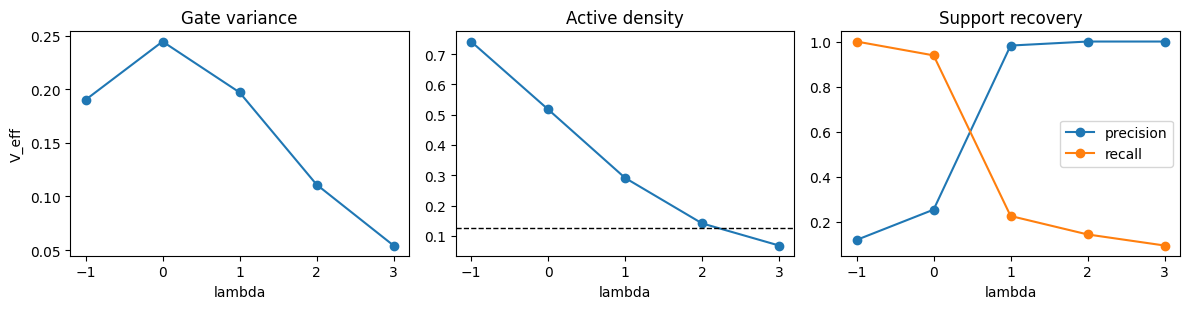

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].plot(df["lambda"], df["v_eff"], marker="o")
axes[0].set_title("Gate variance")
axes[0].set_xlabel("lambda")
axes[0].set_ylabel("V_eff")
axes[1].plot(df["lambda"], df["rho"], marker="o")
axes[1].axhline(cfg.support_density, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Active density")
axes[1].set_xlabel("lambda")
axes[2].plot(df["lambda"], df["support_precision"], marker="o", label="precision")
axes[2].plot(df["lambda"], df["support_recall"], marker="o", label="recall")
axes[2].set_title("Support recovery")
axes[2].set_xlabel("lambda")
axes[2].legend()
fig.tight_layout()
out = OUTPUT_DIR / "exp01_non_amortized"
out.mkdir(parents=True, exist_ok=True)
df.to_csv(out / "non_amortized_lambda_sweep.csv", index=False)
fig.savefig(out / "non_amortized_lambda_sweep.png", dpi=160)


**Read this ruthlessly:** this experiment is not an SAE result yet. It only verifies that the VG support-inference objective has a measurable support-uncertainty response when amortization is removed. If this plot is flat or support recall collapses for all lambda, the amortized VG-SAE experiments are premature.
